# Final Examination: TranslateAI Ancient Character Recognition

Total Marks: 100

**Instructions:**
1. Enter your course email in the cell below.
2. Read the story and problem descriptions carefully.
3. Complete the code in cells containing `# YOUR CODE HERE`. Do not modify the test cells.
4. Run all cells sequentially to ensure your tests pass before submitting.

In [25]:
# Enter your course email here
student_email = "abdurrahmansoftw@gmail.com" # Example: "your.name@university.edu"

---

## 📖 TranslateAI — Digitizing History

You have just been hired as a Machine Learning Engineer at **TranslateAI**, a startup working with international museums. Your first task is to build a neural network that can automatically classify ancient Japanese cursive texts.

We will use the **KMNIST** dataset — 28x28 grayscale images of 10 cursive characters: *o, ki, su, tsu, na, ha, ma, ya, re, wo*.

To ensure top performance, you must optimize your deep learning pipeline using **Batch Normalization** and **Advanced Optimizers (Adam)**.

---

## Question 1: Load, Explore, & Preprocess Data (20 Marks)

### 1.1 Download the Dataset (5 Marks)

We will use `torchvision.datasets.KMNIST` to download the dataset.

Run the cell below to download the training and test sets:

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Class names for KMNIST
class_names = ['o', 'ki', 'su', 'tsu', 'na', 'ha', 'ma', 'ya', 're', 'wo']

# Download KMNIST
full_train_dataset = torchvision.datasets.KMNIST(root='./data', train=True, download=True)
test_dataset_raw = torchvision.datasets.KMNIST(root='./data', train=False, download=True)

print(f"Training set size: {len(full_train_dataset)}")
print(f"Test set size: {len(test_dataset_raw)}")

Training set size: 60000
Test set size: 10000


### 1.2 Visualize Sample Grayscale Images (5 Marks)

Create a **2x5 subplot figure** (figsize 12x5) showing one sample image from **each of the 10 classes**.
- Title each subplot with its class name
- Turn off axis ticks
- Ensure you use `cmap='gray'` for visualization.

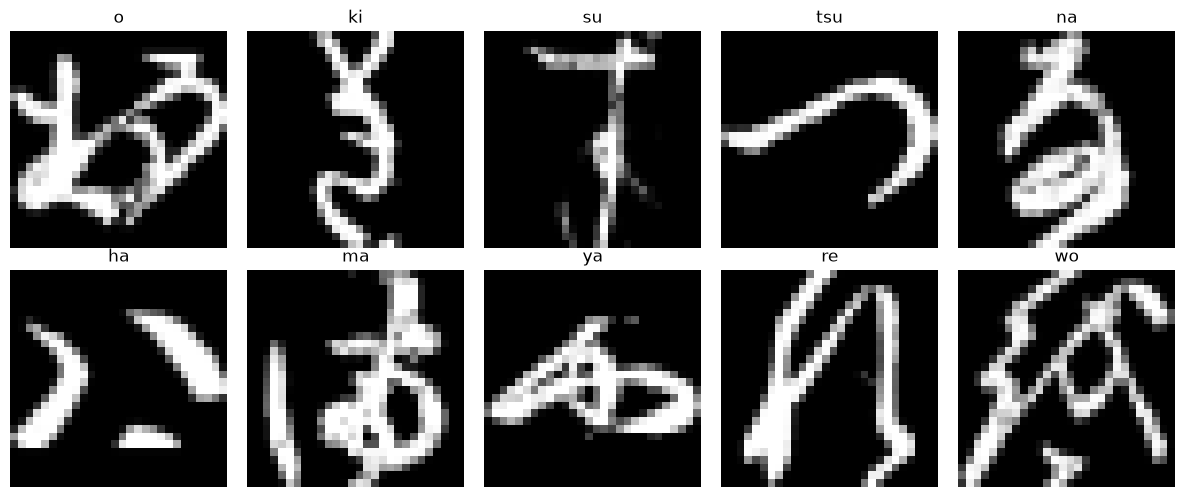

In [27]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()
found = {}
idx = 0
while len(found) < 10 and idx < len(full_train_dataset):
    img, label = full_train_dataset[idx]
    if label not in found:
        found[label] = (img, label)
    idx += 1
for i in range(10):
    img, label = found[i]
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(class_names[label])
    axes[i].axis('off')
plt.tight_layout()
plt.show()


### 1.3 Data Scaling & Splitting (10 Marks)

**Your tasks:**
1. Extract images and labels from both train and test datasets as NumPy arrays. (Note: KMNIST images are 28x28)
2. Normalize the pixel values to the range [0, 1] by MinMax Scaling.
3. Split the training data into **train (50,000)** and **validation (10,000)** using `train_test_split` with `random_state=42`.
4. Convert all sets to PyTorch tensors — images as `float32`, labels as `long`.

**Required variables:** `X_train, X_val, X_test` (float32 tensors), `y_train, y_val, y_test` (long tensors)

In [28]:
# Extract images and labels as numpy arrays
X_full = full_train_dataset.data.numpy().astype('float32')   # (60000, 28, 28)
y_full = full_train_dataset.targets.numpy()
X_test_np = test_dataset_raw.data.numpy().astype('float32')   # (10000, 28, 28)
y_test_np  = test_dataset_raw.targets.numpy()

# MinMax scaling to [0, 1]
X_full    = X_full    / 255.0
X_test_np = X_test_np / 255.0

# Train / Validation split: 50000 / 10000
X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(
    X_full, y_full, test_size=10000, random_state=42
)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train_np, dtype=torch.float32)
X_val   = torch.tensor(X_val_np,   dtype=torch.float32)
X_test  = torch.tensor(X_test_np,  dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.long)
y_val   = torch.tensor(y_val_np,   dtype=torch.long)
y_test  = torch.tensor(y_test_np,  dtype=torch.long)

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_val  : {X_val.shape},   y_val  : {y_val.shape}')
print(f'X_test : {X_test.shape},  y_test : {y_test.shape}')


X_train: torch.Size([50000, 28, 28]), y_train: torch.Size([50000])
X_val  : torch.Size([10000, 28, 28]),   y_val  : torch.Size([10000])
X_test : torch.Size([10000, 28, 28]),  y_test : torch.Size([10000])


In [29]:
# --- TEST CELL (DO NOT MODIFY) ---
assert X_train.shape == (50000, 28, 28), f"Expected (50000, 28, 28), got {X_train.shape}"
assert X_val.shape == (10000, 28, 28)
assert X_train.dtype == torch.float32
assert y_train.dtype == torch.long
print("✅ Q1.3 Passed!")

✅ Q1.3 Passed!


---

## Question 2: Build PyTorch DataLoaders (15 Marks)

Create `TensorDataset` and `DataLoader` objects for train, validation, and test sets.

- **batch_size = 256**
- **shuffle = True** for training, **False** for validation and test

**Required variables:** `train_loader`, `val_loader`, `test_loader`

In [30]:
batch_size = 256

train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val,   y_val)
test_dataset  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Val   batches: {len(val_loader)}')
print(f'Test  batches: {len(test_loader)}')


Train batches: 196
Val   batches: 40
Test  batches: 40


In [31]:
# --- TEST CELL (DO NOT MODIFY) ---
batch_X, batch_y = next(iter(train_loader))
assert batch_X.shape == (256, 28, 28)
assert batch_y.dtype == torch.long
print("✅ Q2 Passed!")

✅ Q2 Passed!


---

## Question 3: Deep Neural Network Architecture (25 Marks)

Create a class `TranslateAIClassifier` inheriting from `nn.Module`.

Use `nn.Sequential` with this architecture. Since the input is `28x28`, the flattened size is **784**.

| Layer | Description |
|-------|-------------|
| Flatten | Convert 28x28 → 784 |
| Linear | 784 → 512 |
| BatchNorm1d | Batch Normalization (512 features) |
| ReLU | Activation |
| Linear | 512 → 256 |
| BatchNorm1d | Batch Normalization (256 features) |
| ReLU | Activation |
| Linear | 256 → 128 |
| BatchNorm1d | Batch Normalization (128 features) |
| ReLU | Activation |
| Linear | 128 → 10 |

After defining the class, create an instance called `model` and print it.

In [32]:
class TranslateAIClassifier(nn.Module):
    def __init__(self):
        super(TranslateAIClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.network(x)

model = TranslateAIClassifier()
print(model)


TranslateAIClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Linear(in_features=256, out_features=128, bias=True)
    (8): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU()
    (10): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [33]:
# --- TEST CELL (DO NOT MODIFY) ---
test_input = torch.randn(5, 28, 28)
test_output = model(test_input)
assert test_output.shape == (5, 10)
has_batchnorm = any(isinstance(m, nn.BatchNorm1d) for m in model.modules())
assert has_batchnorm, "Model must include BatchNorm1d layers"
print("✅ Q3 Passed!")

✅ Q3 Passed!


---

## Question 4: Advanced Training Pipeline (25 Marks)

### 4.1 Setup Optimizer and Loss (5 Marks)
- Loss function: `nn.CrossEntropyLoss`
- Optimizer: `optim.Adam` with `lr=0.001`
- Number of epochs: **15**

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 15

### 4.2 PyTorch Training Pipeline (20 Marks)

Write the training loop for **15 epochs**.

For each epoch:
1. Set model to training mode (`model.train()`)
2. Train on `train_loader` (forward pass, calculate loss, backward pass, optimizer step)
3. Set model to evaluation mode (`model.eval()`)
4. Evaluate on `val_loader` and compute validation loss and accuracy.
5. Print: `Epoch {epoch+1}/{epochs} | Train Loss: {:.4f} | Val Loss: {:.4f}`

Store: `train_losses`, `val_losses` lists.

In [35]:
train_losses = []
val_losses   = []

for epoch in range(epochs):
    # ── Training ──
    model.train()
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_X.size(0)
    train_loss = running_loss / len(train_dataset)

    # ── Validation ──
    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_running_loss += loss.item() * batch_X.size(0)
    val_loss = val_running_loss / len(val_dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f'Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')


Epoch 1/15 | Train Loss: 0.3826 | Val Loss: 0.1880
Epoch 2/15 | Train Loss: 0.1367 | Val Loss: 0.1435
Epoch 3/15 | Train Loss: 0.0804 | Val Loss: 0.1492
Epoch 4/15 | Train Loss: 0.0526 | Val Loss: 0.1418
Epoch 5/15 | Train Loss: 0.0322 | Val Loss: 0.1443
Epoch 6/15 | Train Loss: 0.0274 | Val Loss: 0.1526
Epoch 7/15 | Train Loss: 0.0230 | Val Loss: 0.1384
Epoch 8/15 | Train Loss: 0.0179 | Val Loss: 0.1753
Epoch 9/15 | Train Loss: 0.0159 | Val Loss: 0.1431
Epoch 10/15 | Train Loss: 0.0145 | Val Loss: 0.1523
Epoch 11/15 | Train Loss: 0.0142 | Val Loss: 0.1466
Epoch 12/15 | Train Loss: 0.0156 | Val Loss: 0.1535
Epoch 13/15 | Train Loss: 0.0104 | Val Loss: 0.1575
Epoch 14/15 | Train Loss: 0.0086 | Val Loss: 0.1394
Epoch 15/15 | Train Loss: 0.0137 | Val Loss: 0.1582


In [36]:
# --- TEST CELL (DO NOT MODIFY) ---
assert len(train_losses) == 15, f"Expected 15 epochs, got {len(train_losses)}"
assert len(val_losses) == 15
print("✅ Q4.2 Passed!")

✅ Q4.2 Passed!


---

## Question 5: Evaluation & Analytics (10 Marks)

### 5.1 Test Evaluation (5 Marks)
Evaluate the model on the **test set**.
- Print the Test Accuracy.
- Collect Test dataset's all predictions into a list called `all_preds`.

In [37]:
model.eval()
all_preds = []
correct = 0
total   = 0

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.tolist())
        correct += (predicted == batch_y).sum().item()
        total   += batch_y.size(0)

test_accuracy = 100.0 * correct / total
print(f'Test Accuracy: {test_accuracy:.2f}%')


Test Accuracy: 91.79%


### 5.2 Plot Learning Curves (5 Marks)
Plot **Training Loss** and **Validation Loss** on the same figure across epochs. Include a legend and title.

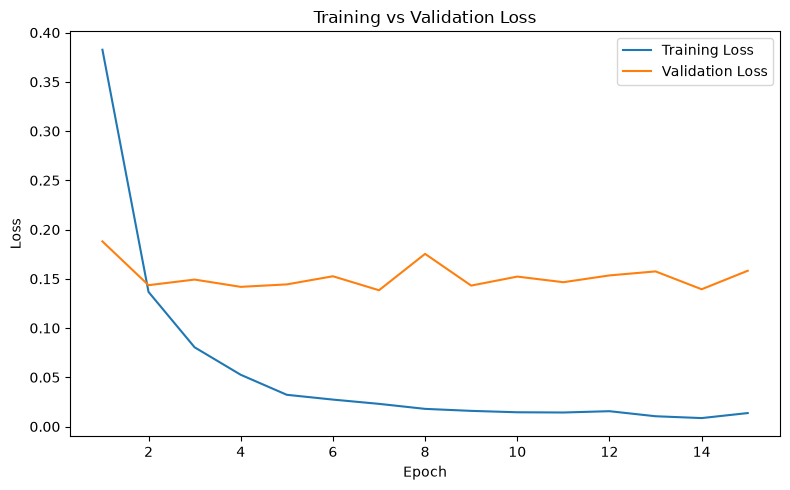

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses,   label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()


### 5.3 Confusion Matrix & Analysis (5+5 Marks)
1. Plot the confusion matrix using `ConfusionMatrixDisplay`.
2. Write a brief markdown explanation of which ancient character classes are most frequently confused by the model based on the matrix.

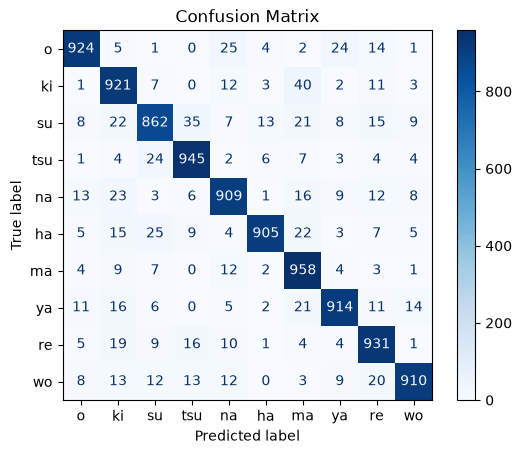

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test.tolist(), all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


**Your Analysis:**

The model correctly predicted most characters. It confused **'ki'** with **'su'** and **'ha'** with **'ma'** the most, because they look similar. Characters like **'o'** and **'wo'** were almost always correct.
